In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import random_split, DataLoader
import matplotlib.pyplot as plt
import numpy as np
import copy
import time
import sys
import os
from tempfile import mktemp

# Exercise 1

In this exercise, you will work with PyTorch, a popular deep learning library developed by Meta.

For any of these tasks, you may also refer to the official PyTorch documentation.

a) Install PyTorch on your machine.

b) Familiarize yourself with the basic concepts of PyTorch Tensors by completing the following tasks:

- Create a tensor `a` with the values $[1, 2, 3, 4]$ and data type float32. What device is it created on?
- Create a tensor `b` with the values $[5, 6, 7, 8]$ and data type int32.
- Convert the data type of `b` to float32.
- Compute the element-wise sum of `a` and `b`.
- Compute the dot product of `a` and `b`.

- Create a tensor `M` with values drawn from a standard normal distribution with shape $4 \times 4$.
- Compute the matrix-vector product of `M` and `a`.

c) Create a simple neural network in PyTorch that consists of a single linear layer with input size 2 and output size 3.

- Pass a batch of 32 samples through the network and print the output.
- Print the weights and biases of the network.
- Save the model to a file and load it again. Is the output identical?

Note that simply saving and loading model weights is not identical to restoring the full training state.
However, it is a common practice to use libraries layered on top of PyTorch (e.g. PyTorch Lightning) for
robust checkpointing and other common utilities.

In [2]:
# torch.Tensor and torch.FloatTensor are equivalent
a = torch.Tensor([1, 2, 3, 4])
b = torch.IntTensor([5, 6, 7, 8])

a.device

device(type='cpu')

In [3]:
b = b.to(torch.float32)

In [4]:
a + b

tensor([ 6.,  8., 10., 12.])

In [5]:
a @ b

tensor(70.)

In [6]:
M = torch.randn(4, 4)

In [7]:
M @ a

tensor([ 3.5152,  3.4852, -0.8013,  6.5253])

In [8]:
net = nn.Linear(2, 3)

In [9]:
batch = torch.randn(32, 2)
net(batch)

tensor([[ 0.1920, -0.1412, -0.3415],
        [-0.3655, -0.7732, -0.5267],
        [ 0.8808,  0.8091, -0.3824],
        [ 0.1790, -0.0168, -0.5671],
        [-0.3971, -0.8833, -0.4192],
        [ 0.5088,  0.2557, -0.2965],
        [-0.1410, -0.2133, -0.9375],
        [-0.1178,  0.1044, -1.3928],
        [ 0.7293,  0.7349, -0.5876],
        [ 0.0833, -0.2008, -0.4788],
        [-0.1474, -0.7448, -0.1065],
        [-0.4659, -1.0707, -0.2682],
        [-0.5619, -1.2175, -0.2397],
        [-0.4025, -0.3259, -1.3164],
        [-0.0926, -0.3734, -0.5797],
        [-0.4974, -1.1739, -0.1714],
        [ 0.2593,  0.2689, -0.8498],
        [ 0.5390,  0.4668, -0.5676],
        [ 0.1097, -0.2583, -0.3311],
        [-0.5735, -0.6812, -1.1165],
        [ 0.5234,  0.3042, -0.3423],
        [ 0.4209, -0.3110,  0.4163],
        [ 0.1075, -0.2864, -0.2913],
        [-0.3011, -0.8443, -0.2764],
        [-0.2947, -0.6652, -0.5472],
        [ 0.1033,  0.0387, -0.8168],
        [-0.0784, -0.6990, -0.0321],
 

In [10]:
print("Weights:")
print(net.weight)

print("\nBiases:")
print(net.bias)

Weights:
Parameter containing:
tensor([[ 0.0186, -0.4470],
        [-0.2146, -0.5721],
        [ 0.3806, -0.0445]], requires_grad=True)

Biases:
Parameter containing:
tensor([-0.0136, -0.3626, -0.4285], requires_grad=True)


In [14]:
tempfile = mktemp()
original_output = net(batch)
torch.save(net.state_dict(), tempfile)

loaded_net = nn.Linear(2, 3)
loaded_net.load_state_dict(torch.load(tempfile, weights_only=True))
net.eval()
loaded_net.eval()
new_output = loaded_net(batch)

In [15]:
print(torch.allclose(original_output, new_output))

True


# Exercise 2

Train a neural network on the Fashion-MNIST dataset which is a benchmark dataset for image classification, consisting of 70,000 grayscale images of ten categories of clothing items. The goal is to train a model that, given a new image of clothing, correctly predicts which of the ten categories it belongs to. Systematically investigate how the following design choices affect performance:

1. Defines a simple 2-layer fully connected MLP with ReLU. Split the training set into train and val set with 50,000 training images and 10,000 validation images. Train for 20 epochs, plot train & val accuracy curves and calculate the test set accuracy for the following tasks:

2. Selects best optimizer among SGD, RMSProp, Adam, by highest test accuracy.

3. Use the best optimizer from above and compare regularization techniques (no regularization, dropout, early stopping, and dropout + early stopping) by training for 50 epochs. Select the best regularization strategy by highest test accuracy.

4. Use the best optimizer and regularization method from above and compare Learning-rate scheduling (step decay, cosine decay).

5. Vary model architecture (e.g. a simple MLP vs. a small convolutional network, different depths/widths). For each architecture, uses best optimizer + best regularization + best LR schedule found so far. Train up to 50 epochs (with early stopping if enabled). Select the best architecture by highest test accuracy.

Identify the best combination and explain your reasoning.

Note: You can use google colab which provides free GPU for a limited time for training. You can also use Kaggle which provides faster GPUs for 30 hours per week which is sufficient for this task.

In [ ]:
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [ ]:
BATCH_SIZE = 128

transform_basic = transforms.Compose([
    transforms.ToTensor(),            # Scales PIL image [0,255] → [0.0,1.0]
])

# download train+val, split 50k/10k
full_train = datasets.FashionMNIST(root="./data", train=True, download=True, transform=transform_basic)
train_set, val_set = random_split(full_train, [50000, 10000], generator=torch.Generator().manual_seed(SEED))

test_set = datasets.FashionMNIST(root="./data", train=False, download=True, transform=transform_basic)

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

100%|██████████| 26.4M/26.4M [00:01<00:00, 14.3MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 210kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.88MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 15.8MB/s]


In [ ]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += images.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += images.size(0)
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

In [ ]:
def plot_curves(histories, title, ylabel="Accuracy"):
    """
    histories: dict of {label: (list_epochs, list_vals)}.
    e.g. {"Adam Train": ([1,2,3], [0.8,0.85,0.88]), "Adam Val": ([1,2,3], [0.78,0.82,0.86])}
    """
    plt.figure(figsize=(6,4))
    for label, (xs, ys) in histories.items():
        plt.plot(xs, ys, label=label)
    plt.xlabel("Epoch")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [ ]:
# Baseline MLP

class BaselineMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28*28, 512)
        self.fc2 = nn.Linear(512, 256)
        self.out = nn.Linear(256, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.out(x)
        return x


def run_baseline_mlp():
    print("\n--- Running Baseline MLP (Adam, LR=1e-3) ---")
    model = BaselineMLP().to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    num_epochs = 20
    train_hist = {"loss": [], "acc": []}
    val_hist   = {"loss": [], "acc": []}

    for epoch in range(1, num_epochs+1):
        t_loss, t_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        v_loss, v_acc = evaluate(model, val_loader, criterion, device)
        train_hist["loss"].append(t_loss)
        train_hist["acc"].append(t_acc)
        val_hist["loss"].append(v_loss)
        val_hist["acc"].append(v_acc)
        print(f"Epoch {epoch:02d} | Train Acc: {t_acc:.4f}, Val Acc: {v_acc:.4f}")

    test_loss, test_acc = evaluate(model, test_loader, criterion, device)
    print(f"Baseline MLP Test Acc: {test_acc:.4f}")
    plot_curves(
        {"Train Acc": (list(range(1,num_epochs+1)), train_hist["acc"]),
         "Val Acc":   (list(range(1,num_epochs+1)), val_hist["acc"])},
        title="Baseline MLP Accuracy"
    )
    return test_acc

In [ ]:
# Optimizer Comparison (SGD, RMSProp, Adam)

def run_optimizer_comparison():
    print("\n--- Optimizer Comparison ---")
    optimizers = {
        "SGD":    lambda params: optim.SGD(params, lr=0.1, momentum=0.9),
        "RMSProp":lambda params: optim.RMSprop(params, lr=1e-3),
        "Adam":   lambda params: optim.Adam(params, lr=1e-3),
    }

    num_epochs = 20
    criterion = nn.CrossEntropyLoss()
    results = {}

    for opt_name, opt_fn in optimizers.items():
        print(f"\nOptimizer: {opt_name}")
        model = BaselineMLP().to(device)
        optimizer = opt_fn(model.parameters())

        train_acc_hist = []
        val_acc_hist = []

        for epoch in range(1, num_epochs+1):
            _, t_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
            _, v_acc = evaluate(model, val_loader, criterion, device)
            train_acc_hist.append(t_acc)
            val_acc_hist.append(v_acc)
            print(f"  Epoch {epoch:02d} | Val Acc: {v_acc:.4f}", end="\r")

        test_loss, test_acc = evaluate(model, test_loader, criterion, device)
        print(f"\n  {opt_name} Test Acc: {test_acc:.4f}")
        results[opt_name] = {
            "train_acc": train_acc_hist,
            "val_acc":   val_acc_hist,
            "test_acc":  test_acc
        }

    # Plot all three on one chart
    epochs = list(range(1, num_epochs+1))
    histories = {}
    for opt_name in optimizers:
        histories[f"{opt_name} Train"] = (epochs, results[opt_name]["train_acc"])
        histories[f"{opt_name} Val"]   = (epochs, results[opt_name]["val_acc"])
    plot_curves(histories, title="Optimizer Comparison: Train & Val Accuracy")

    for opt_name, res in results.items():
        print(f"{opt_name} Test Acc: {res['test_acc']:.4f}")
    return results

In [ ]:
# Regularization (Dropout & Early Stopping)

class MLPWithDropout(nn.Module):
    def __init__(self, dropout_prob=0.5):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28*28, 512)
        self.drop1 = nn.Dropout(dropout_prob)
        self.fc2 = nn.Linear(512, 256)
        self.drop2 = nn.Dropout(dropout_prob)
        self.out = nn.Linear(256, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = F.relu(self.fc1(x))
        x = self.drop1(x)
        x = F.relu(self.fc2(x))
        x = self.drop2(x)
        x = self.out(x)
        return x


def run_regularization_experiments(best_optimizer_name):
    print(f"\n--- Regularization Experiments (Using Optimizer: {best_optimizer_name}) ---")
    # Hyperparams
    MAX_EPOCHS = 50
    PATIENCE = 5
    criterion = nn.CrossEntropyLoss()
    optimizer_fns = {
        "SGD":    lambda params: optim.SGD(params, lr=0.1, momentum=0.9),
        "RMSProp":lambda params: optim.RMSprop(params, lr=1e-3),
        "Adam":   lambda params: optim.Adam(params, lr=1e-3),
    }
    opt_fn = optimizer_fns[best_optimizer_name]

    def train_with_config(use_dropout, use_early_stop):
        if use_dropout:
            model = MLPWithDropout(dropout_prob=0.5).to(device)
        else:
            model = BaselineMLP().to(device)

        optimizer = opt_fn(model.parameters())
        best_val_acc = 0.0
        patience_counter = 0

        hist = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

        for epoch in range(1, MAX_EPOCHS+1):
            t_loss, t_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
            v_loss, v_acc = evaluate(model, val_loader, criterion, device)

            hist["train_loss"].append(t_loss)
            hist["val_loss"].append(v_loss)
            hist["train_acc"].append(t_acc)
            hist["val_acc"].append(v_acc)

            if use_early_stop:
                if v_acc > best_val_acc:
                    best_val_acc = v_acc
                    best_model_wts = copy.deepcopy(model.state_dict())
                    patience_counter = 0
                else:
                    patience_counter += 1

                if patience_counter >= PATIENCE:
                    print(f"  Early stopping at epoch {epoch}")
                    model.load_state_dict(best_model_wts)
                    break

            print(f"  Epoch {epoch:02d} | Val Acc: {v_acc:.4f}", end="\r")

        test_loss, test_acc = evaluate(model, test_loader, criterion, device)
        return model, hist, test_acc

    configs = {
        "Baseline (no reg)": (False, False),
        "Dropout only":       (True,  False),
        "EarlyStop only":     (False, True),
        "Dropout + EarlyStop":(True,  True),
    }

    results = {}
    for label, (drop, es) in configs.items():
        print(f"\nConfiguration: {label}")
        model, hist, test_acc = train_with_config(drop, es)
        print(f"  Test Acc: {test_acc:.4f}")
        results[label] = {"hist": hist, "test_acc": test_acc}

    # Plot validation loss curves
    plt.figure(figsize=(6,4))
    for label, res in results.items():
        epochs = list(range(1, len(res["hist"]["val_loss"]) + 1))
        plt.plot(epochs, res["hist"]["val_loss"], label=label)
    plt.xlabel("Epoch")
    plt.ylabel("Validation Loss")
    plt.title("Validation Loss under Different Regularization")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    for label, res in results.items():
        print(f"{label} → Test Acc: {res['test_acc']:.4f}")
    return results

In [ ]:
# Learning-Rate Scheduling

def run_lr_scheduling(best_optimizer_name, best_reg_config):
    print(f"\n--- Learning-Rate Scheduling (Optimizer: {best_optimizer_name}, Reg: {best_reg_config}) ---")
    MAX_EPOCHS = 50
    criterion = nn.CrossEntropyLoss()
    optimizer_fns = {
        "SGD":    lambda params: optim.SGD(params, lr=0.1, momentum=0.9),
        "RMSProp":lambda params: optim.RMSprop(params, lr=1e-3),
        "Adam":   lambda params: optim.Adam(params, lr=1e-3),
    }
    opt_fn = optimizer_fns[best_optimizer_name]

    def get_model_by_reg(reg_label):
        if "Dropout" in reg_label:
            return MLPWithDropout(dropout_prob=0.5).to(device)
        else:
            return BaselineMLP().to(device)

    # Two schedules
    def train_with_scheduler(scheduler_type):
        model = get_model_by_reg(best_reg_config)
        optimizer = opt_fn(model.parameters())

        if scheduler_type == "StepDecay":
            scheduler = optim.lr_scheduler.MultiStepLR(optimizer, milestones=[15, 30], gamma=0.1)
        elif scheduler_type == "CosineDecay":
            scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=MAX_EPOCHS)
        else:
            raise ValueError

        hist = {"lr": [], "val_acc": []}

        for epoch in range(1, MAX_EPOCHS+1):
            for images, labels in train_loader:
                images, labels = images.to(device), labels.to(device)
                optimizer.zero_grad()
                outputs = model(images)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
            scheduler.step()

            current_lr = optimizer.param_groups[0]['lr']
            v_loss, v_acc = evaluate(model, val_loader, criterion, device)
            hist["lr"].append(current_lr)
            hist["val_acc"].append(v_acc)
            print(f"  {scheduler_type:12s} | Epoch {epoch:02d} | LR: {current_lr:.5f} | Val Acc: {v_acc:.4f}", end="\r")

        test_loss, test_acc = evaluate(model, test_loader, criterion, device)
        print(f"\n  {scheduler_type} Test Acc: {test_acc:.4f}")
        return hist, test_acc

    results = {}
    for sched in ["StepDecay", "CosineDecay"]:
        print(f"\nSchedule: {sched}")
        hist, test_acc = train_with_scheduler(sched)
        results[sched] = {"hist": hist, "test_acc": test_acc}

    # Plot LR vs epoch & Val Acc vs epoch
    plt.figure(figsize=(10,4))
    for i, sched in enumerate(results):
        plt.subplot(1, 2, i+1)
        epochs = list(range(1, len(results[sched]["hist"]["lr"])+1))
        plt.plot(epochs, results[sched]["hist"]["lr"])
        plt.xlabel("Epoch"); plt.ylabel("Learning Rate")
        plt.title(f"{sched} LR Schedule")
        plt.grid(True)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10,4))
    for i, sched in enumerate(results):
        plt.subplot(1, 2, i+1)
        epochs = list(range(1, len(results[sched]["hist"]["val_acc"])+1))
        plt.plot(epochs, results[sched]["hist"]["val_acc"])
        plt.xlabel("Epoch"); plt.ylabel("Val Accuracy")
        plt.title(f"{sched} Val Acc")
        plt.grid(True)
    plt.tight_layout()
    plt.show()

    for sched, res in results.items():
        print(f"{sched} → Test Acc: {res['test_acc']:.4f}")
    return results

In [ ]:
# Architecture Exploration (Small CNN & Deeper CNN)

class SmallCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)  # 28×28 → 28×28
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1) # 28×28 → 28×28
        self.pool  = nn.MaxPool2d(2, 2)                          # 28×28 → 14×14
        self.fc1   = nn.Linear(64*14*14, 128)
        self.dropout = nn.Dropout(0.5)
        self.out   = nn.Linear(128, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = self.pool(x)
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.out(x)
        return x


class DeeperCNN(nn.Module):
    def __init__(self):
        super().__init__()
        # Block 1
        self.conv1a = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.conv1b = nn.Conv2d(32, 32, kernel_size=3, padding=1)
        # Block 2
        self.conv2a = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv2b = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.pool   = nn.MaxPool2d(2,2)  # halves spatial dims
        self.fc1    = nn.Linear(64*7*7, 256)
        self.dropout = nn.Dropout(0.5)
        self.out    = nn.Linear(256, 10)

    def forward(self, x):
        # Block 1
        x = F.relu(self.conv1a(x))
        x = F.relu(self.conv1b(x))
        x = self.pool(x)  # now 14x14
        # Block 2
        x = F.relu(self.conv2a(x))
        x = F.relu(self.conv2b(x))
        x = self.pool(x)  # now 7x7
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.out(x)
        return x


def run_architecture_exploration(best_optimizer_name, best_reg_config, best_lr_sched):
    print(f"\n--- Architecture Exploration (Optimizer={best_optimizer_name}, Reg={best_reg_config}, LR={best_lr_sched}) ---")
    criterion = nn.CrossEntropyLoss()

    optimizer_fns = {
        "SGD":    lambda params: optim.SGD(params, lr=0.1, momentum=0.9),
        "RMSProp":lambda params: optim.RMSprop(params, lr=1e-3),
        "Adam":   lambda params: optim.Adam(params, lr=1e-3),
    }
    opt_fn = optimizer_fns[best_optimizer_name]

    # Helper: load model by name
    def get_model(name):
        if name == "MLP":
            if "Dropout" in best_reg_config:
                return MLPWithDropout(dropout_prob=0.5).to(device)
            else:
                return BaselineMLP().to(device)
        elif name == "SmallCNN":
            return SmallCNN().to(device)
        elif name == "DeeperCNN":
            return DeeperCNN().to(device)
        else:
            raise ValueError

    # Helper: attach LR scheduler as before
    def get_scheduler(optimizer, sched_type):
        if sched_type == "StepDecay":
            return optim.lr_scheduler.MultiStepLR(optimizer, milestones=[15,30], gamma=0.1)
        elif sched_type == "CosineDecay":
            return optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)
        else:
            return None

    architectures = ["MLP", "SmallCNN", "DeeperCNN"]
    results = {}

    for arch in architectures:
        print(f"\nArchitecture: {arch}")
        model = get_model(arch)
        optimizer = opt_fn(model.parameters())
        scheduler = get_scheduler(optimizer, best_lr_sched)
        best_val_acc = 0.0
        patience_counter = 0
        hist = {"train_acc": [], "val_acc": []}

        for epoch in range(1, 51):  # up to 50 epochs
            # train
            model.train()
            for images, labels in train_loader:
                images, labels = images.to(device), labels.to(device)
                optimizer.zero_grad()
                outputs = model(images)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
            if scheduler:
                scheduler.step()

            t_loss, t_acc = evaluate(model, train_loader, criterion, device)
            v_loss, v_acc = evaluate(model, val_loader, criterion, device)
            hist["train_acc"].append(t_acc)
            hist["val_acc"].append(v_acc)

            # early stopping if specified
            if "EarlyStop" in best_reg_config:
                if v_acc > best_val_acc:
                    best_val_acc = v_acc
                    best_wts = copy.deepcopy(model.state_dict())
                    patience_counter = 0
                else:
                    patience_counter += 1
                if patience_counter >= 5:
                    model.load_state_dict(best_wts)
                    print(f"  Early stopping at epoch {epoch}")
                    break

            print(f"  Epoch {epoch:02d} | Val Acc: {v_acc:.4f}", end="\r")

        test_loss, test_acc = evaluate(model, test_loader, criterion, device)
        print(f"\n  {arch} Test Acc: {test_acc:.4f}")
        results[arch] = {"hist": hist, "test_acc": test_acc}

    # Plot validation accuracy for all architectures
    plt.figure(figsize=(6,4))
    for arch in architectures:
        epochs = list(range(1, len(results[arch]["hist"]["val_acc"]) + 1))
        plt.plot(epochs, results[arch]["hist"]["val_acc"], label=arch)
    plt.xlabel("Epoch"); plt.ylabel("Val Accuracy")
    plt.title("Validation Accuracy: MLP vs. SmallCNN vs. DeeperCNN")
    plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

    for arch, res in results.items():
        print(f"{arch} → Test Acc: {res['test_acc']:.4f}")
    return results


--- Running Baseline MLP (Adam, LR=1e-3) ---
Epoch 01 | Train Acc: 0.8043, Val Acc: 0.8496
Epoch 02 | Train Acc: 0.8617, Val Acc: 0.8671
Epoch 03 | Train Acc: 0.8778, Val Acc: 0.8756
Epoch 04 | Train Acc: 0.8848, Val Acc: 0.8742
Epoch 05 | Train Acc: 0.8928, Val Acc: 0.8868
Epoch 06 | Train Acc: 0.8972, Val Acc: 0.8836
Epoch 07 | Train Acc: 0.9015, Val Acc: 0.8866
Epoch 08 | Train Acc: 0.9084, Val Acc: 0.8889
Epoch 09 | Train Acc: 0.9088, Val Acc: 0.8771
Epoch 10 | Train Acc: 0.9133, Val Acc: 0.8936
Epoch 11 | Train Acc: 0.9183, Val Acc: 0.8943
Epoch 12 | Train Acc: 0.9217, Val Acc: 0.8908
Epoch 13 | Train Acc: 0.9253, Val Acc: 0.8933
Epoch 14 | Train Acc: 0.9280, Val Acc: 0.8956
Epoch 15 | Train Acc: 0.9295, Val Acc: 0.8944
Epoch 16 | Train Acc: 0.9326, Val Acc: 0.8900
Epoch 17 | Train Acc: 0.9350, Val Acc: 0.8932
Epoch 18 | Train Acc: 0.9388, Val Acc: 0.8910
Epoch 19 | Train Acc: 0.9391, Val Acc: 0.8971
Epoch 20 | Train Acc: 0.9422, Val Acc: 0.8981
Baseline MLP Test Acc: 0.8921


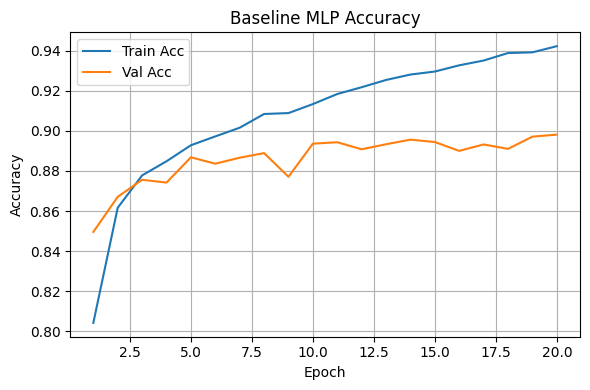


--- Optimizer Comparison ---

Optimizer: SGD

  SGD Test Acc: 0.8794

Optimizer: RMSProp

  RMSProp Test Acc: 0.8793

Optimizer: Adam

  Adam Test Acc: 0.8959


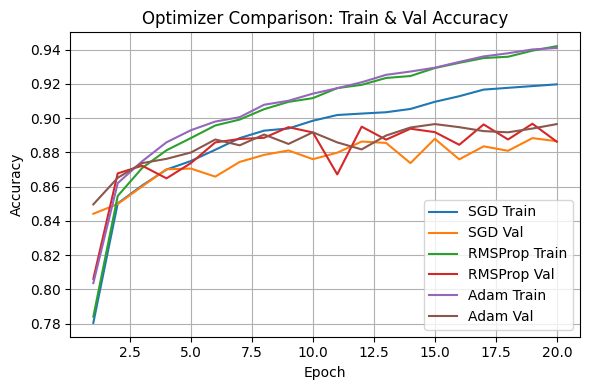

SGD Test Acc: 0.8794
RMSProp Test Acc: 0.8793
Adam Test Acc: 0.8959

Best optimizer: Adam

--- Regularization Experiments (Using Optimizer: Adam) ---

Configuration: Baseline (no reg)
  Test Acc: 0.8869

Configuration: Dropout only
  Test Acc: 0.8901

Configuration: EarlyStop only
  Early stopping at epoch 18
  Test Acc: 0.8914

Configuration: Dropout + EarlyStop
  Early stopping at epoch 19
  Test Acc: 0.8811


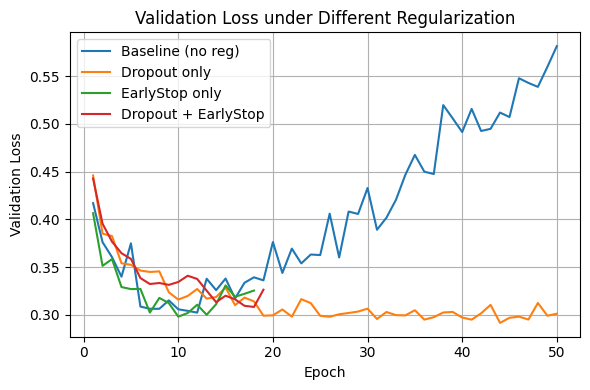

Baseline (no reg) → Test Acc: 0.8869
Dropout only → Test Acc: 0.8901
EarlyStop only → Test Acc: 0.8914
Dropout + EarlyStop → Test Acc: 0.8811

Best regularization: EarlyStop only

--- Learning-Rate Scheduling (Optimizer: Adam, Reg: EarlyStop only) ---

Schedule: StepDecay

  StepDecay Test Acc: 0.8984

Schedule: CosineDecay

  CosineDecay Test Acc: 0.8986


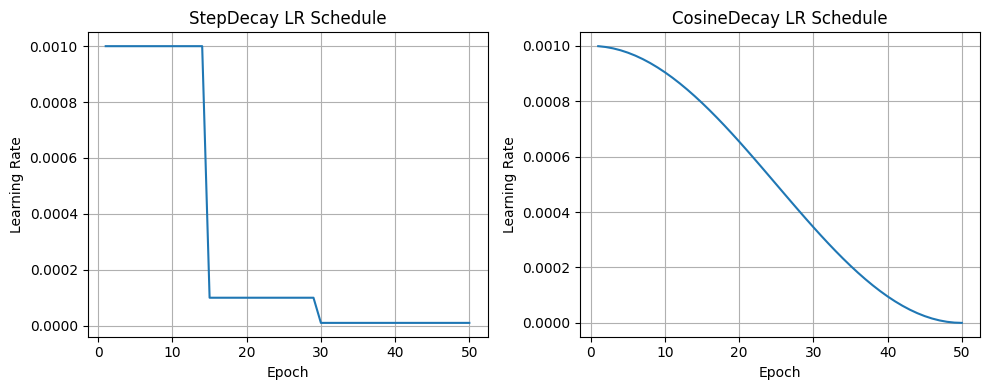

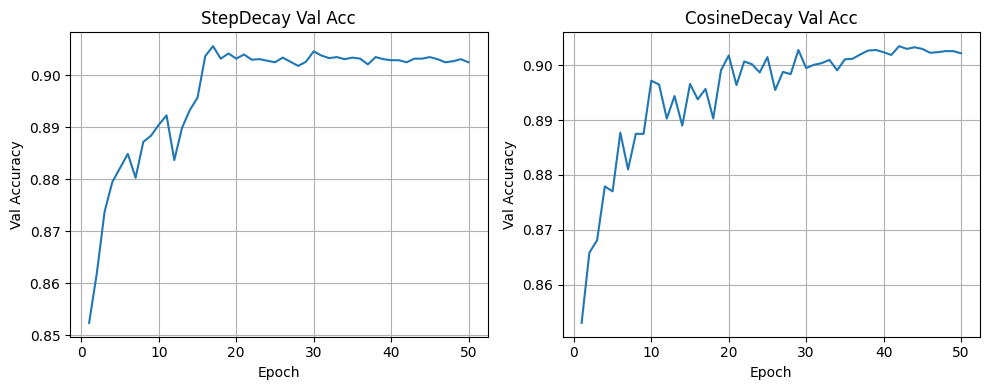

StepDecay → Test Acc: 0.8984
CosineDecay → Test Acc: 0.8986

Best LR schedule: CosineDecay

--- Architecture Exploration (Optimizer=Adam, Reg=EarlyStop only, LR=CosineDecay) ---

Architecture: MLP
  Early stopping at epoch 29

  MLP Test Acc: 0.9012

Architecture: SmallCNN
  Early stopping at epoch 33

  SmallCNN Test Acc: 0.9292

Architecture: DeeperCNN
  Early stopping at epoch 18

  DeeperCNN Test Acc: 0.9260


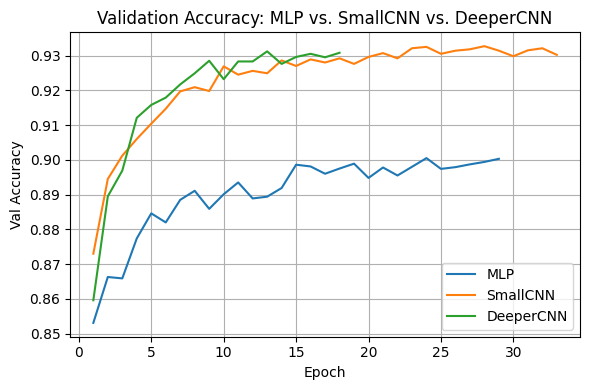

MLP → Test Acc: 0.9012
SmallCNN → Test Acc: 0.9292
DeeperCNN → Test Acc: 0.9260

Best architecture: SmallCNN

--- Summary of Best Choices ---
Optimizer:        Adam
Regularization:   EarlyStop only
LR Schedule:      CosineDecay
Architecture:     SmallCNN
Baseline Test Acc:  0.8921
Experiment complete.


In [ ]:
# Putting It All Together

if __name__ == "__main__":
    # 1. Baseline
    baseline_test_acc = run_baseline_mlp()

    # 2. Optimizer Comparison
    optim_results = run_optimizer_comparison()
    # Find best optimizer by highest test accuracy
    best_optimizer = max(optim_results.keys(), key=lambda k: optim_results[k]['test_acc'])
    print(f"\nBest optimizer: {best_optimizer}")

    # 3. Regularization (use best optimizer)
    reg_results = run_regularization_experiments(best_optimizer)
    # Find best regularization config by highest test_acc
    best_reg = max(reg_results.keys(), key=lambda k: reg_results[k]['test_acc'])
    print(f"\nBest regularization: {best_reg}")

    # 4. Learning‐Rate Scheduling (use best optimizer + best regularization)
    lr_results = run_lr_scheduling(best_optimizer, best_reg)
    # Pick the schedule with highest test accuracy
    best_lr = max(lr_results.keys(), key=lambda k: lr_results[k]['test_acc'])
    print(f"\nBest LR schedule: {best_lr}")

    # 5. Architecture Exploration (use best optimizer + best reg + best lr)
    arch_results = run_architecture_exploration(best_optimizer, best_reg, best_lr)
    # Choose the architecture with highest test acc
    best_arch = max(arch_results.keys(), key=lambda k: arch_results[k]['test_acc'])
    print(f"\nBest architecture: {best_arch}")

    print("\n--- Summary of Best Choices ---")
    print(f"Optimizer:        {best_optimizer}")
    print(f"Regularization:   {best_reg}")
    print(f"LR Schedule:      {best_lr}")
    print(f"Architecture:     {best_arch}")
    #print(f"Augmented Test Acc: {aug_test_acc:.4f}")
    print(f"Baseline Test Acc:  {baseline_test_acc:.4f}")
    print("Experiment complete.")
